In [ ]:
library(tidyverse)

In [ ]:
library(pheatmap)

In [ ]:
library(GenomicRanges)

In [ ]:
library(clusterProfiler)

In [ ]:
library(org.Hs.eg.db)

In [6]:
DoGO <- function(gene){
    gene_id <- clusterProfiler::bitr(gene,fromType = "ALIAS",toType="ENTREZID", OrgDb="org.Hs.eg.db")
    data_go <- enrichGO(gene = 
                             gene_id$ENTREZID,
                             OrgDb = org.Hs.eg.db,
                             ont = "BP",
                             pAdjustMethod = "BH",
                             qvalueCutoff = 0.05,
                             pvalueCutoff = 0.05,
                             readable = TRUE
                        )
    return(data_go)
}

In [7]:
DoKEGG <- function(gene){
    gene_id <- clusterProfiler::bitr(gene,fromType = "ALIAS",toType="ENTREZID", OrgDb="org.Hs.eg.db")
    gene_id2 = gene_id$ENTREZID
    data_kegg <- enrichKEGG(gene        = gene_id2,
                         organism     = 'hsa',
                          qvalueCutoff = 0.05,
                         pvalueCutoff = 0.05)
    for(i in 1:nrow(data_kegg@result)){
        data_kegg@result$geneID[i]  %>% str_split('/')  %>% .[[1]] ->a
        a2 <- bitr(a, fromType="ENTREZID", toType="SYMBOL", OrgDb="org.Hs.eg.db")
        paste0(a2$SYMBOL ,collapse = '/') -> a3
        data_kegg@result$geneID[i] <- a3
}
    return(data_kegg)
}

In [194]:
library(RColorBrewer)
get_plot <- function(C2_go,C3_go){
    C2_go %>% as.data.frame()  -> C2_temp
    C3_go %>% as.data.frame() -> C3_temp
    C2_temp  %>% dplyr::select(Description,GeneRatio,p.adjust,Count) %>% 
        mutate(group = "GC2") -> C2_temp2
    C3_temp  %>% dplyr::select(Description,GeneRatio,p.adjust,Count)  %>% 
        mutate(Description=Description,group = "GC3") -> C3_temp2
            
    if(nrow(C2_temp2)>20){
        C2_temp2 = C2_temp2[1:20,]
    }else if(nrow(C2_temp2)>0){
        C2_temp2 = C2_temp2[1:nrow(C2_temp2),]
    }else{
        C2_temp2 = C2_temp
    }
        
    if(nrow(C3_temp2)>20){
        C3_temp2 = C3_temp2[1:20,]
    }else if(nrow(C3_temp2)>0){
        C3_temp2 = C3_temp2[1:nrow(C3_temp2),]
    }else{
        C3_temp2 = C3_temp
    }
    
    rbind(C2_temp2,C3_temp2) -> C1_C2_C3_comb
    
   # C1_C2_C3_comb  %>% mutate(GeneRatio2 = ifelse(group=="C2",'C2','C3')) -> C1_C2_C3_comb
    
    C1_C2_C3_comb$Description  <- factor(C1_C2_C3_comb$Description,levels = unique(C1_C2_C3_comb  %>% arrange((Count)) %>% .[,1]))

        
    mat <- C1_C2_C3_comb %>%
      dplyr::select(Description, group, p.adjust) %>%
      pivot_wider(names_from = group, values_from = p.adjust, values_fill = 1) %>%
      column_to_rownames("Description") %>%
      as.matrix()   
    row_dist <- dist(mat)
        row_clust <- hclust(row_dist)
        row_order <- row_clust$order
        description_ordered <- rownames(mat)[row_order]
    C1_C2_C3_comb$Description <- factor(C1_C2_C3_comb$Description, levels = description_ordered)

    p <- ggplot(data = C1_C2_C3_comb) + 
      geom_point(aes(x = group, y = Description, size = Count, color = p.adjust)) + 
      theme(panel.background = element_rect(fill = NA),
            panel.grid.major.y = element_line(color = 'gray', linetype = 'dashed'),
            axis.text = element_text(color = 'black'),
            panel.border = element_rect(fill = NA, color = 'black')) +
      geom_vline(xintercept = 0) +
      ylab('') + xlab('') + 
      theme(axis.text.y = element_text(size = 11)) +
      scale_colour_gradientn(colors = colorRampPalette(c("red", "blue"))(80))
    return(p)
}

In [57]:
hubs <- read.table('all.hubs',header=T)

In [58]:
mGC2_loop_anno2 <- readRDS(file = "mGC2_loop_anno2.Rds")
mGC3_loop_anno2 <- readRDS(file = "mGC3_loop_anno2.Rds")

In [59]:
paste(hubs$chr,hubs$start,hubs$end,sep="_") -> names
rownames(hubs) <- names

In [60]:
hubs2 <- hubs[,4:ncol(hubs)]

In [61]:
mGC2 <- c('U3008', 'U3031', 'U3073')
mGC3 <- c('U3013', 'U3039', 'U3078','U3118','U3121')

In [62]:
hubs_mGC2 <- hubs2[,mGC2]
hubs_mGC3 <- hubs2[,mGC3]

In [64]:
#hubs_mGC2_filtered <- hubs_mGC2[apply(hubs_mGC2, 1, function(x) all(x > 0)), ]
#hubs_mGC3_filtered <- hubs_mGC3[apply(hubs_mGC3, 1, function(x) sum(x > 0) >= 3), ]

In [65]:
dim(hubs_mGC2_filtered);dim(hubs_mGC3_filtered)

[1] 5369    3

[1] 6727    5

In [171]:
# Reusable function to get intersected top 10% rownames across columns
get_common_top_regions <- function(df) {
  get_top_by_rank <- function(col) {
    # Get the indices of non-zero values
    non_zero_idx <- which(col != 0)
    non_zero_col <- col[non_zero_idx]
    
    # Calculate how many top values we want to select (10% of non-zero values)
    n_top <- max(1, ceiling(length(non_zero_col) * 0.05))
    
    # Get the indices of the top n non-zero values based on the original column
    top_idx <- non_zero_idx[order(non_zero_col, decreasing = TRUE)[1:n_top]]
    
    # Return the rownames based on the top indices
    rownames(df)[top_idx]
  }
  
  top_lists <- lapply(df, get_top_by_rank)
  Reduce(union, top_lists)
}

# Apply to your three datasets
hubs_mGC2_filtererd_index <- get_common_top_regions(hubs_mGC2)
hubs_mGC3_filtererd_index <- get_common_top_regions(hubs_mGC3)

In [172]:
hubs_mGC2[hubs_mGC2_filtererd_index,] -> hubs_mGC2_filtererdtop10
hubs_mGC3[hubs_mGC3_filtererd_index,] -> hubs_mGC3_filtererdtop10

In [173]:
dim(hubs_mGC2_filtererdtop10);dim(hubs_mGC3_filtererdtop10)

[1] 2045    3

[1] 1475    5

In [174]:
hubs_mGC2_filtererdtop10  %>% rownames() -> mGC2_rownames
hubs_mGC3_filtererdtop10  %>% rownames() -> mGC3_rownames

In [175]:
library(VennDiagram)
library("ggvenn")

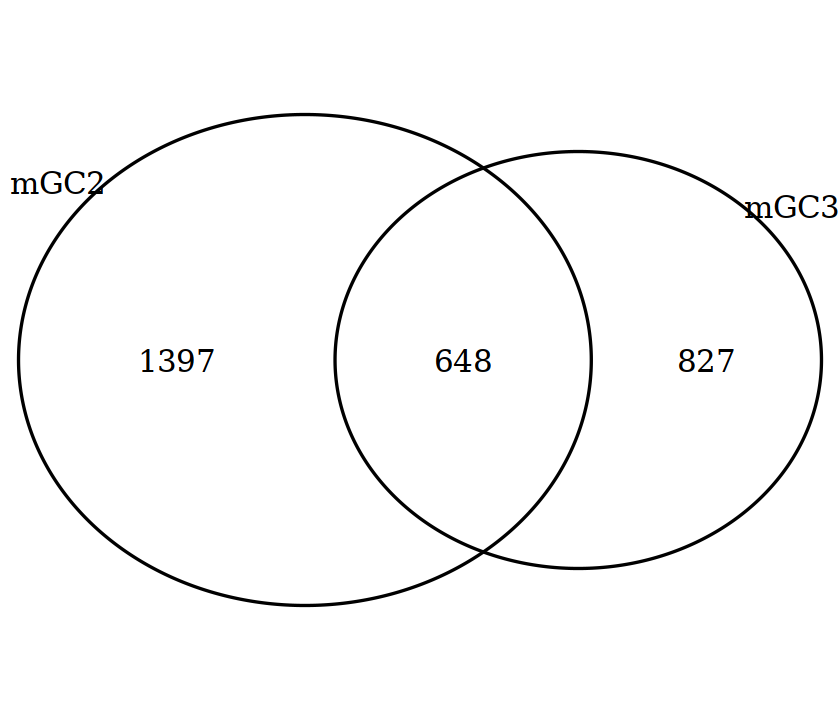

In [176]:
#pdf("Venn.Specific.Peaks.pdf", width=4, height=4)
options(repr.plot.height=6,repr.plot.width=7)
venn.plot <- venn.diagram(
  x = list(
    mGC2 = mGC2_rownames,
    mGC3 = mGC3_rownames
  ),
  filename = NULL,  # Important: do NOT write directly to file here
  fill = NULL,
  alpha = 0.5,
  cex = 1.5,
  cat.cex = 1.5,
#  cat.pos = c(-20, 20)
)
grid.draw(venn.plot)

#dev.off()

In [177]:
mGC2_rownames  %>%  setdiff(mGC3_rownames)  %>% hubs_mGC2_filtererdtop10[.,] -> hubs_mGC2_filteredtop10
mGC3_rownames  %>%  setdiff(mGC2_rownames)  %>% hubs_mGC3_filtererdtop10[.,] -> hubs_mGC3_filteredtop10

### add anno

In [178]:
add_genesymbol <- function(hubs_mGC1_filtererdtop10,mGC1_loop_anno2){
    # 1. Convert row names into GRanges
    hubs_mGC1_filtererdtop10_peaks <- rownames(hubs_mGC1_filtererdtop10) %>%
      str_split("_") %>%
      do.call(rbind, .) %>%
      as.data.frame() %>%
      setNames(c("chr", "start", "end")) %>%
      makeGRangesFromDataFrame()

    # 2. Create GRanges for left and right anchors
    Left_ranges <- mGC1_loop_anno2 %>%
      dplyr::select(chrL, startL, endL) %>%
      dplyr::rename(chr = chrL, start = startL, end = endL) %>%
      makeGRangesFromDataFrame()

    Right_ranges <- mGC1_loop_anno2 %>%
      dplyr::select(chrR, startR, endR) %>%
      dplyr::rename(chr = chrR, start = startR, end = endR) %>%
      makeGRangesFromDataFrame()

    # 3. Perform overlaps
    left_hits <- findOverlaps(hubs_mGC1_filtererdtop10_peaks, Left_ranges) %>% as.data.frame()
    right_hits <- findOverlaps(hubs_mGC1_filtererdtop10_peaks, Right_ranges) %>% as.data.frame()

    # 4. Helper to map hits to gene symbols
    map_genes <- function(hits_df) {
      hits_df %>%
        mutate(GeneSym = mGC1_loop_anno2$GeneSym[subjectHits]) %>%
        group_by(queryHits) %>%
        summarise(GeneSym = paste(unique(unlist(strsplit(GeneSym, ","))), collapse = ","), .groups = "drop")
    }

    # 5. Map genes
    mapped_genes_left <- map_genes(left_hits)
    mapped_genes_right <- map_genes(right_hits)

    # 6. Assign mapped genes
    hubs_mGC1_filtererdtop10_peaks$GeneSym1 <- mapped_genes_left$GeneSym[match(seq_along(hubs_mGC1_filtererdtop10_peaks), mapped_genes_left$queryHits)]
    hubs_mGC1_filtererdtop10_peaks$GeneSym2 <- mapped_genes_right$GeneSym[match(seq_along(hubs_mGC1_filtererdtop10_peaks), mapped_genes_right$queryHits)]

    # 7. Replace NAs with empty strings
    hubs_mGC1_filtererdtop10_peaks$GeneSym1[is.na(hubs_mGC1_filtererdtop10_peaks$GeneSym1)] <- ""
    hubs_mGC1_filtererdtop10_peaks$GeneSym2[is.na(hubs_mGC1_filtererdtop10_peaks$GeneSym2)] <- ""

    # 8. Merge gene symbols uniquely
    hubs_mGC1_filtererdtop10_peaks$MergedGeneSym <- mapply(function(a, b) {
      paste(unique(c(strsplit(a, ",")[[1]], strsplit(b, ",")[[1]])), collapse = ",")
    }, hubs_mGC1_filtererdtop10_peaks$GeneSym1, hubs_mGC1_filtererdtop10_peaks$GeneSym2)

    # 9. Extract final result
    hubs_mGC1_filtererdtop10_peaks <- as.data.frame(hubs_mGC1_filtererdtop10_peaks) %>%
      dplyr::select(seqnames, start, end, MergedGeneSym)
    return(hubs_mGC1_filtererdtop10_peaks)
}


In [179]:
hubs_mGC2_filtererdtop10_peaks <- add_genesymbol(hubs_mGC2_filteredtop10,mGC2_loop_anno2)

In [180]:
hubs_mGC3_filtererdtop10_peaks <- add_genesymbol(hubs_mGC3_filteredtop10,mGC3_loop_anno2)

In [181]:
hubs_mGC2_filtererdtop10_peaks   %>% pull(MergedGeneSym)  %>% str_split(',')  %>% unlist()  %>% unique()  -> mGC2_hub_genes
hubs_mGC3_filtererdtop10_peaks   %>% pull(MergedGeneSym)  %>% str_split(',')  %>% unlist()  %>% unique()  -> mGC3_hub_genes

In [182]:
library(VennDiagram)
library("ggvenn")

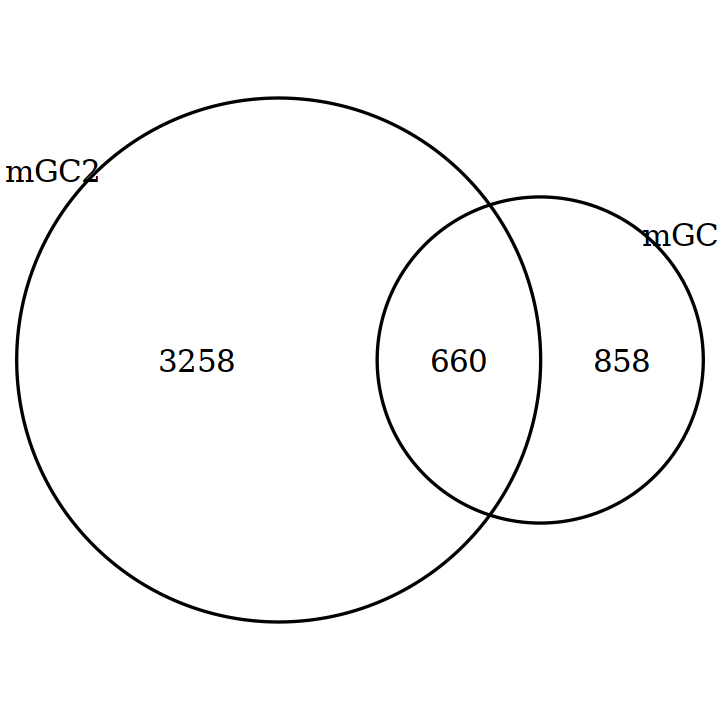

In [183]:
#pdf("Venn.Specific.Hubgenes.pdf", width=4, height=4)
options(repr.plot.height=6,repr.plot.width=6)
venn.plot <- venn.diagram(
  x = list(
    mGC2 = mGC2_hub_genes,
    mGC3 = mGC3_hub_genes
  ),
  filename = NULL,  # Important: do NOT write directly to file here
  fill = NULL,
  alpha = 0.5,
  cex = 1.5,
  cat.cex = 1.5,
 # cat.pos = c(-20, 20, 0)
)
grid.draw(venn.plot)
#dev.off()

In [184]:
mGC2_hub_genes  %>% setdiff(mGC3_hub_genes)-> mGC2_hub_spec_genes
mGC3_hub_genes  %>% setdiff(mGC2_hub_genes)-> mGC3_hub_spec_genes

In [185]:
length(mGC2_hub_spec_genes);length(mGC3_hub_spec_genes)

[1] 3258

[1] 858

In [186]:
mGC2_go <- DoGO(mGC2_hub_spec_genes)
mGC3_go <- DoGO(mGC3_hub_spec_genes)

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



In [198]:
p_go_combine <- get_plot(mGC2_go,mGC3_go)

In [199]:
mGC2_kegg@result$Description  %>% str_split(' - ')  %>% map_chr(~ .x[1])  %>% unlist() -> mGC2_kegg@result$Description
mGC3_kegg@result$Description  %>% str_split(' - ')  %>% map_chr(~ .x[1])  %>% unlist() -> mGC3_kegg@result$Description

In [200]:
options(repr.plot.height=8,repr.plot.width=9)
p_kegg_combine <- get_plot(mGC2_kegg,mGC3_kegg)

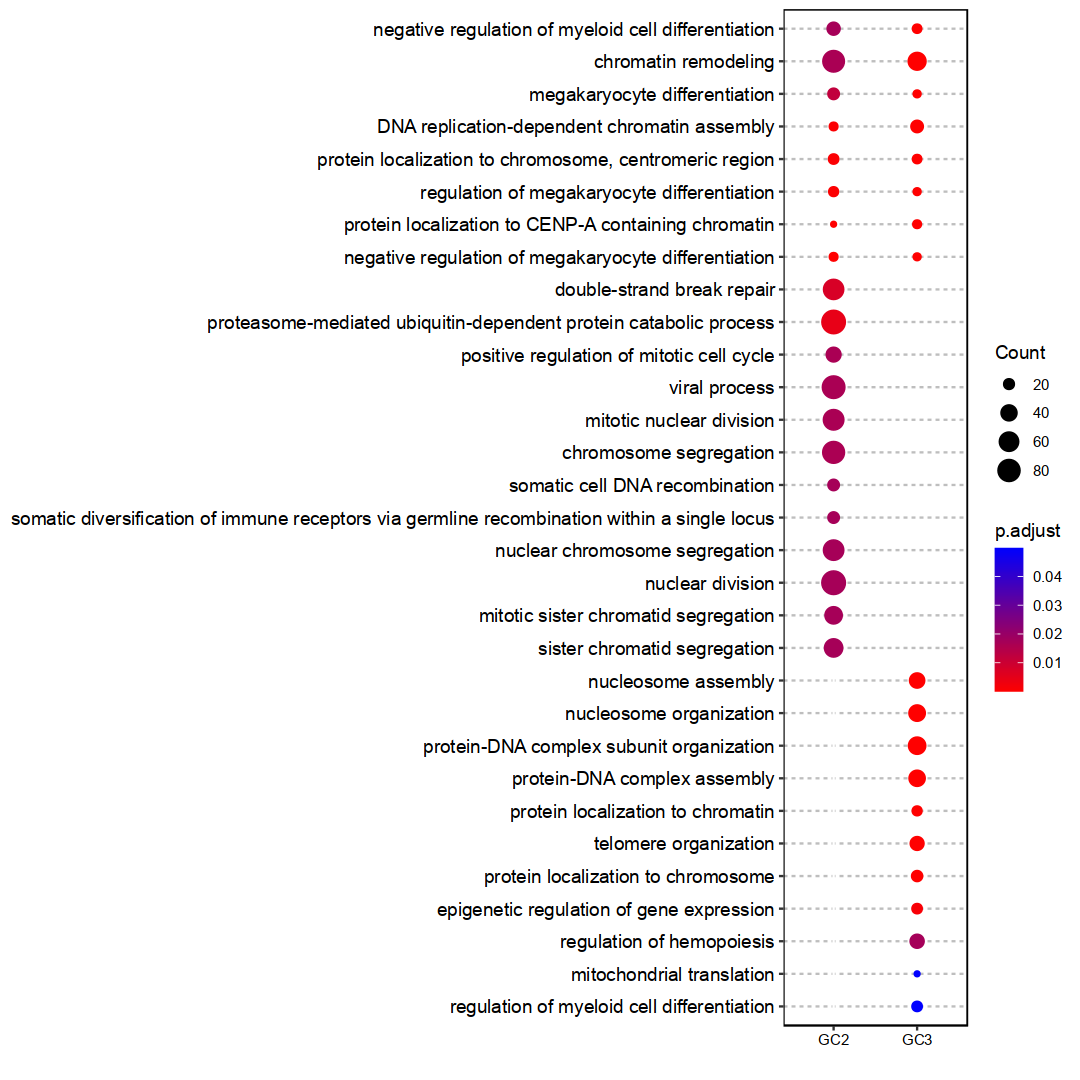

In [203]:
options(repr.plot.height=9,repr.plot.width=9)
p_go_combine

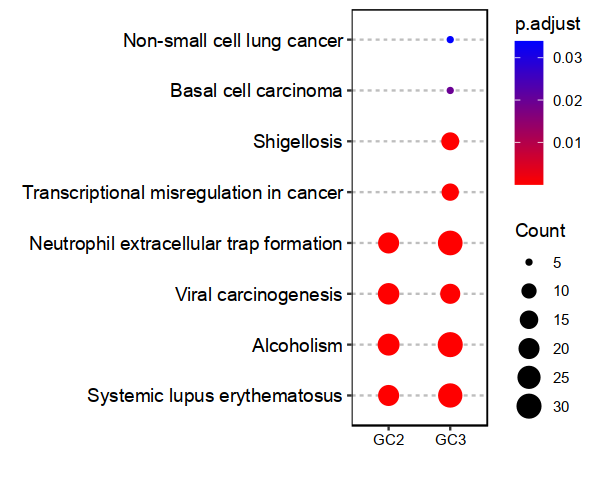

In [204]:
options(repr.plot.height=4,repr.plot.width=5)
p_kegg_combine

In [ ]:
library(simplifyEnrichment)
set.seed(888)

In [169]:
active_mat_mGC2 = GO_similarity(mGC2_go %>% as.data.frame() %>% rownames(),ont="BP")
active_mat_mGC3 = GO_similarity(mGC3_go %>% as.data.frame() %>% rownames(),ont="BP")

In [170]:
pdf(file ="Hubs_GO_simplify_GC2_heatmap.pdf" ,width = 9,height = 6)
df_act_C2 = simplifyGO(active_mat_mGC2)
dev.off()
pdf(file ="Hubs_GO_simplify_GC3_heatmap.pdf" ,width = 9,height = 6)
df_act_C3 = simplifyGO(active_mat_mGC3)
dev.off()

Cluster 155 terms by 'binary_cut'...
 12 clusters, used 0.6001325 secs.

Perform keywords enrichment for 8 GO lists...



pdf 
  2

Cluster 22 terms by 'binary_cut'...
 5 clusters, used 0.05665708 secs.

Perform keywords enrichment for 5 GO lists...



pdf 
  2